# FinCare: Datasets and exploratory data analysis

**Goal:** understand the data before modelling next-day S&P 500 returns.

All data is pulled from Yahoo Finance with the `yfinance` library; no downloaded CSVs are needed. The notebook builds each table in the same format as the original Kaggle / FRED files.

**Table 2: Data sources**

| Source                     | Series           | Built in the format of | What we use                                                                                    | Link                                                                        |
| -------------------------- | ---------------- | ---------------------- | ---------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| Yahoo Finance (`yfinance`) | `^GSPC`          | `sp500_index.csv`      | Daily S&P 500 level → target return                                                            | [finance.yahoo.com/quote/%5EGSPC](https://finance.yahoo.com/quote/%5EGSPC/) |
| Yahoo Finance (`yfinance`) | Top 50 tickers   | `sp500_stocks.csv`     | Daily open, high, low, close, adjusted close and volume                                        | [pypi.org/project/yfinance](https://pypi.org/project/yfinance/)             |
| Yahoo Finance (`yfinance`) | Company profiles | `sp500_companies.csv`  | Name, sector, market cap; `Weight` = index weight as of Dec 2024 (fixed, listed in the config) | Same                                                                        |
| Yahoo Finance (`yfinance`) | `^VIX`           | `VIXCLS.csv`           | Daily VIX close (market-fear index)                                                            | [finance.yahoo.com/quote/%5EVIX](https://finance.yahoo.com/quote/%5EVIX/)   |

**Prep steps**

1. Rank the tickers by index weight; take the top 50 (keep one of GOOGL / GOOG, so take the 51st).
2. Download daily prices for those tickers, the index and the VIX for a fixed period; one column per stock.
3. Merge the index, stocks and VIX on `Date`; drop missing days.
4. Compute daily returns; target = index return shifted one day ahead.

**Reproducibility:** the period and the ticker list are fixed, and the first run saves a snapshot to `yfinance_data/`. Later runs read the snapshot, so results do not change as Yahoo adds new days or market caps move.


## 1. Setup


In [1]:
# Run once if yfinance is not installed:
# %pip install yfinance

In [2]:
import json
import os
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

In [ ]:
# ---- Configuration ----
START_DATE = "2021-01-01"
END_DATE = "2026-09-23"  # exclusive: data runs to 2026-09-22
INDEX_TICKER = "^GSPC"
VIX_TICKER = "^VIX"

SAVE_DIR = "yfinance_data"  # snapshot saved here on the first run
REFRESH_DOWNLOAD = False  # True = pull from Yahoo again and overwrite the snapshot

TOP_N = 50
SHARE_CLASS_DUPES = [("GOOGL", "GOOG")]  # keep one share class per company
VIX_STRESS = 20  # VIX at or above this = "stressed" market

# Intended tickers: the top 50 S&P 500 stocks by index weight as of Dec 2024,
# plus GOOG and 10 spares in case a download fails. Weight = share of total index market cap.
# Kept fixed so the stock list does not change between runs.
TICKER_WEIGHTS = {
    "AAPL": 0.069209,
    "NVDA": 0.059350,
    "MSFT": 0.058401,
    "AMZN": 0.042550,
    "GOOGL": 0.042309,
    "GOOG": 0.042309,
    "META": 0.026581,
    "TSLA": 0.024317,
    "AVGO": 0.018553,
    "BRK-B": 0.017609,
    "WMT": 0.013332,
    "LLY": 0.012422,
    "JPM": 0.012035,
    "V": 0.011069,
    "MA": 0.008719,
    "ORCL": 0.008537,
    "XOM": 0.008371,
    "UNH": 0.008281,
    "COST": 0.007619,
    "PG": 0.007121,
    "HD": 0.007016,
    "NFLX": 0.006991,
    "JNJ": 0.006258,
    "BAC": 0.006097,
    "CRM": 0.005917,
    "ABBV": 0.005582,
    "KO": 0.004848,
    "TMUS": 0.004600,
    "CVX": 0.004582,
    "MRK": 0.004462,
    "WFC": 0.004213,
    "CSCO": 0.004193,
    "ACN": 0.004123,
    "NOW": 0.004051,
    "AXP": 0.003785,
    "MCD": 0.003773,
    "PEP": 0.003771,
    "BX": 0.003728,
    "IBM": 0.003716,
    "DIS": 0.003650,
    "LIN": 0.003635,
    "TMO": 0.003606,
    "MS": 0.003578,
    "ABT": 0.003565,
    "ADBE": 0.003541,
    "AMD": 0.003481,
    "PM": 0.003475,
    "ISRG": 0.003361,
    "PLTR": 0.003301,
    "GE": 0.003278,
    "INTU": 0.003240,
    "GS": 0.003197,
    # spares
    "CAT": 0.003180,
    "TXN": 0.003067,
    "QCOM": 0.003056,
    "VZ": 0.003024,
    "BKNG": 0.003006,
    "DHR": 0.002970,
    "T": 0.002937,
    "BLK": 0.002866,
    "RTX": 0.002789,
}

OUT = "eda_outputs"
os.makedirs(OUT, exist_ok=True)

# Chart style (matches the baselines notebook)
NAVY, GREY, ACCENT, LIGHT = "#0f2d6b", "#9aa5b1", "#b24a28", "#c9d2d9"
SOURCE_NOTE = "Source: Yahoo Finance via yfinance (^GSPC, ^VIX, top 50 S&P 500 stocks)"


def style(ax):
    ax.spines[["top", "right"]].set_visible(False)


def title(ax, text, size=12):
    ax.set_title(text, fontsize=size, fontweight="bold", loc="left")

## 2. Pull the data from Yahoo Finance

Each table is built in the same format as the original files:

| Table        | Same format as        | Columns                                                                                                                                                                         |
| ------------ | --------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `companies`  | `sp500_companies.csv` | `Exchange, Symbol, Shortname, Longname, Sector, Industry, Currentprice, Marketcap, Ebitda, Revenuegrowth, City, State, Country, Fulltimeemployees, Longbusinesssummary, Weight` |
| `index_raw`  | `sp500_index.csv`     | `Date, S&P500`, one row per trading day                                                                                                                                         |
| `stocks_raw` | `sp500_stocks.csv`    | `Date, Symbol, Adj Close, Close, High, Low, Open, Volume`; one row for every trading day × every ticker (blank where there is no price), tickers in company-name order          |
| `vix_raw`    | `VIXCLS.csv` (FRED)   | `observation_date, VIXCLS`; one row per weekday, blank on market holidays                                                                                                       |

The first run saves these as CSVs with the same file names in `yfinance_data/`.


In [ ]:
FIELDS = ["Adj Close", "Close", "High", "Low", "Open", "Volume"]
COMPANY_COLS = {  # sp500_companies.csv column -> yfinance .info key
    "Exchange": "exchange",
    "Shortname": "shortName",
    "Longname": "longName",
    "Sector": "sector",
    "Industry": "industry",
    "Currentprice": "currentPrice",
    "Marketcap": "marketCap",
    "Ebitda": "ebitda",
    "Revenuegrowth": "revenueGrowth",
    "City": "city",
    "State": "state",
    "Country": "country",
    "Fulltimeemployees": "fullTimeEmployees",
    "Longbusinesssummary": "longBusinessSummary",
}
FILES = {
    name: os.path.join(SAVE_DIR, f"{name}.csv")
    for name in ["sp500_companies", "sp500_index", "sp500_stocks", "VIXCLS"]
}


def yf_download(tickers):
    raw = yf.download(
        tickers,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        actions=False,
        group_by="column",
        progress=False,
        threads=True,
    )
    if not isinstance(raw.columns, pd.MultiIndex):  # older yfinance, single ticker
        raw.columns = pd.MultiIndex.from_product([raw.columns, [tickers[0]]])
    return raw


def close_series(ticker):
    return yf_download([ticker])["Close"].iloc[:, 0].dropna()


def build_companies(tickers):
    rows = []
    for sym in tickers:
        try:
            info = yf.Ticker(sym).info or {}
        except Exception as e:
            print(f"No company profile for {sym}: {e}")
            info = {}
        rows.append(
            {"Symbol": sym, **{col: info.get(key) for col, key in COMPANY_COLS.items()}}
        )
    df = pd.DataFrame(rows)
    df["Weight"] = df["Symbol"].map(TICKER_WEIGHTS)
    cols = (
        ["Exchange", "Symbol"]
        + [c for c in COMPANY_COLS if c != "Exchange"]
        + ["Weight"]
    )
    return df[cols].sort_values("Weight", ascending=False).reset_index(drop=True)


def to_long(raw):
    """Wide yfinance frame -> Date, Symbol, Adj Close, Close, High, Low, Open, Volume."""
    try:
        long = raw.stack(level=1, future_stack=True)
    except TypeError:  # pandas < 2.1
        long = raw.stack(level=1)
    long = long.reset_index()
    long.columns = ["Date", "Symbol"] + [str(c) for c in long.columns[2:]]
    return long[["Date", "Symbol"] + FIELDS].dropna(subset=["Close"])


def build_stocks(tickers, dates, companies):
    """sp500_stocks.csv layout: full Date x Symbol grid, blank where no price."""
    long = to_long(yf_download(tickers))
    for t in sorted(set(tickers) - set(long["Symbol"])):  # one retry per failed ticker
        try:
            long = pd.concat([long, to_long(yf_download([t]))])
        except Exception as e:
            print(f"Retry failed for {t}: {e}")
    names = (
        companies.set_index("Symbol")["Longname"]
        .astype("string")
        .fillna(pd.Series(companies["Symbol"].values, index=companies["Symbol"]))
    )
    name_order = names.str.lower().sort_values().index.tolist()
    grid = pd.MultiIndex.from_product([name_order, dates], names=["Symbol", "Date"])
    out = (
        long.drop_duplicates(["Symbol", "Date"])
        .set_index(["Symbol", "Date"])
        .reindex(grid)
        .reset_index()
    )
    out["Date"] = out["Date"].dt.strftime("%Y-%m-%d")
    return out[["Date", "Symbol"] + FIELDS]


def build_vix():
    """VIXCLS.csv (FRED) layout: every weekday, blank on market holidays."""
    vix = close_series(VIX_TICKER).round(2)
    weekdays = pd.bdate_range(START_DATE, pd.Timestamp(END_DATE) - pd.Timedelta(days=1))
    out = (
        vix.reindex(weekdays)
        .rename("VIXCLS")
        .rename_axis("observation_date")
        .reset_index()
    )
    out["observation_date"] = out["observation_date"].dt.strftime("%Y-%m-%d")
    return out

In [ ]:
if REFRESH_DOWNLOAD or not all(os.path.exists(f) for f in FILES.values()):
    os.makedirs(SAVE_DIR, exist_ok=True)
    tickers = list(TICKER_WEIGHTS)

    companies = build_companies(tickers)

    index_close = close_series(INDEX_TICKER)
    index_df = index_close.rename("S&P500").rename_axis("Date").reset_index()
    index_df["Date"] = index_df["Date"].dt.strftime("%Y-%m-%d")

    stocks_df = build_stocks(tickers, pd.DatetimeIndex(index_close.index), companies)
    vix_df = build_vix()

    companies.to_csv(FILES["sp500_companies"], index=False)
    index_df.to_csv(FILES["sp500_index"], index=False)
    stocks_df.to_csv(FILES["sp500_stocks"], index=False)
    vix_df.to_csv(FILES["VIXCLS"], index=False)
    with open(os.path.join(SAVE_DIR, "download_info.json"), "w") as f:
        json.dump(
            {
                "downloaded_at": datetime.now().isoformat(timespec="seconds"),
                "yfinance_version": yf.__version__,
                "start": START_DATE,
                "end_exclusive": END_DATE,
                "tickers": tickers,
            },
            f,
            indent=2,
        )
    print(f"Pulled from Yahoo Finance and saved a snapshot to {SAVE_DIR}/")
else:
    print(
        f"Using the saved snapshot in {SAVE_DIR}/ (set REFRESH_DOWNLOAD = True to pull again)"
    )

# Read back from the snapshot so every run uses identical data
companies = pd.read_csv(FILES["sp500_companies"])
index_raw = pd.read_csv(FILES["sp500_index"], parse_dates=["Date"])
stocks_raw = pd.read_csv(FILES["sp500_stocks"], parse_dates=["Date"])
vix_raw = pd.read_csv(FILES["VIXCLS"], parse_dates=["observation_date"]).rename(
    columns={"observation_date": "Date", "VIXCLS": "VIX"}
)

for name, df in [
    ("sp500_companies", companies),
    ("sp500_index", index_raw),
    ("sp500_stocks", stocks_raw),
    ("VIXCLS", vix_raw),
]:
    print(f"{name:16s} {df.shape[0]:>9,} rows x {df.shape[1]} columns")

no_prices = sorted(
    set(companies["Symbol"]) - set(stocks_raw.dropna(subset=["Close"])["Symbol"])
)
if no_prices:
    print(f"No prices for: {no_prices}")

Pulled from Yahoo Finance and saved a snapshot to yfinance_data/
sp500_companies         61 rows x 16 columns
sp500_index          1,435 rows x 2 columns
sp500_stocks        87,535 rows x 8 columns
VIXCLS               1,493 rows x 2 columns


In [6]:
stocks_raw.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2021-01-04,ABT,97.868484,109.110001,110.250000,107.260002,109.529999,6192000
1,2021-01-05,ABT,99.079391,110.459999,110.910004,108.300003,108.849998,4322800
2,2021-01-06,ABT,98.873100,110.230003,111.029999,108.589996,108.949997,5539600
3,2021-01-07,ABT,99.832848,111.300003,111.620003,109.250000,110.279999,5568800
4,2021-01-08,ABT,100.110924,111.610001,112.550003,110.339996,111.669998,4242200


## 3. Prep step 1: rank tickers by index weight


In [7]:
ranked = companies.sort_values("Weight", ascending=False).reset_index(drop=True)
ranked["Rank"] = ranked.index + 1
ranked[["Rank", "Symbol", "Shortname", "Sector", "Weight"]].head(10)

,Rank,Symbol,Shortname,Sector,Weight
0,1,AAPL,Apple Inc.,Technology,0.069209
1,2,NVDA,NVIDIA Corporation,Technology,0.059350
2,3,MSFT,Microsoft Corporation,Technology,0.058401
3,4,AMZN,"Amazon.com, Inc.",Consumer Cyclical,0.042550
4,5,GOOGL,Alphabet Inc.,Communication Services,0.042309
5,6,GOOG,Alphabet Inc.,Communication Services,0.042309
6,7,META,"Meta Platforms, Inc.",Communication Services,0.026581
7,8,TSLA,"Tesla, Inc.",Consumer Cyclical,0.024317
8,9,AVGO,Broadcom Inc.,Technology,0.018553
9,10,BRK-B,Berkshire Hathaway Inc. New,Financial Services,0.017609


### Coverage check

Each source must cover the whole study period, otherwise the merge in step 6 silently shortens the dataset.


In [ ]:
def coverage(df, name, value_col):
    d = df.dropna(subset=[value_col])
    return {
        "source": name,
        "first date": d["Date"].min().date(),
        "last date": d["Date"].max().date(),
        "rows with data": len(d),
        "rows missing": int(df[value_col].isna().sum()),
    }


cov = pd.DataFrame(
    [
        coverage(index_raw, f"Index ({INDEX_TICKER})", "S&P500"),
        coverage(stocks_raw, "Stock prices", "Close"),
        coverage(vix_raw, f"VIX ({VIX_TICKER})", "VIX"),
    ]
)
display(cov)

start = pd.Timestamp(START_DATE)
for _, r in cov.iterrows():
    if pd.Timestamp(r["first date"]) > start + pd.Timedelta(days=7):
        print(
            f"WARNING: {r['source']} starts {r['first date']}, after START_DATE {START_DATE}. "
            "The merged data will start late."
        )
last_common = cov["last date"].min()
print(f"Merged data can only run up to {last_common} (the earliest 'last date' above).")

,source,first date,last date,rows with data,rows missing
0,Index (^GSPC),2021-01-04,2026-09-21,1435,0
1,Stock prices,2021-01-04,2026-09-21,87535,0
2,VIX (^VIX),2021-01-04,2026-09-21,1437,56


Merged data can only run up to 2026-09-21 (the earliest 'last date' above).


## 4. Confirm the top 50 stocks


In [ ]:
first_seen = stocks_raw.dropna(subset=["Close"]).groupby("Symbol")["Date"].min()
sibling = {a: b for a, b in SHARE_CLASS_DUPES} | {b: a for a, b in SHARE_CLASS_DUPES}

top, skipped, last_rank = [], [], None
for _, row in ranked.iterrows():
    sym = row["Symbol"]
    if sibling.get(sym) in top:
        skipped.append((row["Rank"], sym, "other share class already selected"))
        continue
    if sym not in first_seen.index:
        skipped.append((row["Rank"], sym, "no prices downloaded"))
        continue
    if first_seen[sym] > pd.Timestamp(START_DATE) + pd.Timedelta(days=7):
        skipped.append((row["Rank"], sym, "listed after the start date"))
        continue
    top.append(sym)
    if len(top) == TOP_N:
        last_rank = row["Rank"]
        break

if last_rank is None:
    print(
        f"WARNING: only {len(top)} usable tickers. Add spare tickers to TICKER_WEIGHTS and set REFRESH_DOWNLOAD = True."
    )
else:
    print(
        f"Selected {len(top)} tickers, reaching down to weight rank {last_rank} of {len(ranked)}."
    )
skipped = pd.DataFrame(skipped, columns=["Weight rank", "Symbol", "Reason skipped"])
if len(skipped):
    print("Skipped:")
    display(skipped)

top50 = ranked[ranked["Symbol"].isin(top)][
    ["Rank", "Symbol", "Shortname", "Sector", "Weight"]
]
top50 = top50.assign(Weight=(top50["Weight"] * 100).round(2)).rename(
    columns={"Weight": "Weight (%)"}
)
top50.to_csv(f"{OUT}/top50_tickers.csv", index=False)
print(f"Top {TOP_N} together make up {top50['Weight (%)'].sum():.1f}% of the index")
top50.head(10)

Selected 50 tickers, reaching down to weight rank 51 of 61.
Skipped:


,Weight rank,Symbol,Reason skipped
0,6,GOOG,other share class already selected


Top 50 together make up 59.0% of the index


,Rank,Symbol,Shortname,Sector,Weight (%)
0,1,AAPL,Apple Inc.,Technology,6.92
1,2,NVDA,NVIDIA Corporation,Technology,5.94
2,3,MSFT,Microsoft Corporation,Technology,5.84
3,4,AMZN,"Amazon.com, Inc.",Consumer Cyclical,4.26
4,5,GOOGL,Alphabet Inc.,Communication Services,4.23
6,7,META,"Meta Platforms, Inc.",Communication Services,2.66
7,8,TSLA,"Tesla, Inc.",Consumer Cyclical,2.43
8,9,AVGO,Broadcom Inc.,Technology,1.86
9,10,BRK-B,Berkshire Hathaway Inc. New,Financial Services,1.76
10,11,WMT,Walmart Inc.,Consumer Defensive,1.33


**Sector mix of the top 50**


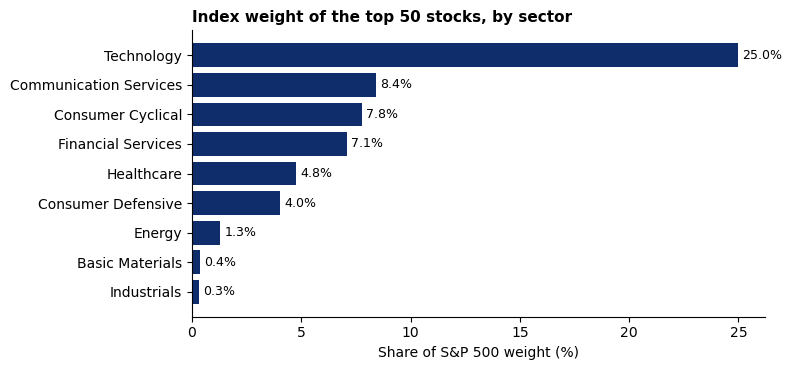

In [10]:
sec = top50.groupby("Sector")["Weight (%)"].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(sec.index, sec.values, color=NAVY)
for i, v in enumerate(sec.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Share of S&P 500 weight (%)")
title(ax, f"Index weight of the top {TOP_N} stocks, by sector", 11)
style(ax)
fig.tight_layout()
fig.savefig(f"{OUT}/fig_top50_sectors.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Reshape to one column per stock

`Adj Close` is used for returns because it corrects for stock splits and dividends (e.g. NVDA's 2024 split); raw `Close` would show a fake crash on split days.


In [ ]:
FIELDS = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

s = stocks_raw[stocks_raw["Symbol"].isin(top) & (stocks_raw["Date"] >= START_DATE)]
if END_DATE:
    s = s[s["Date"] < END_DATE]

stock_missing = int(s["Close"].isna().sum())
wide = s.pivot(index="Date", columns="Symbol", values=FIELDS)
wide.columns = [f"{sym}_{field.replace(' ', '')}" for field, sym in wide.columns]
wide = wide[sorted(wide.columns)]
print(
    f"Stocks, wide format: {wide.shape[0]:,} days x {wide.shape[1]} columns "
    f"({len(top)} stocks x {len(FIELDS)} fields); {stock_missing} blank price rows"
)
wide.iloc[:3, :6]

Stocks, wide format: 1,435 days x 300 columns (50 stocks x 6 fields); 0 blank price rows


,AAPL_AdjClose,AAPL_Close,AAPL_High,AAPL_Low,AAPL_Open,AAPL_Volume
Date,,,,,,
2021-01-04,125.632492,129.410004,133.610001,126.760002,133.520004,143301900.0
2021-01-05,127.185783,131.009995,131.740005,128.429993,128.889999,97664900.0
2021-01-06,122.904518,126.599998,131.050003,126.379997,127.720001,155088000.0


## 6. Prep step 3: merge index, stocks and VIX on date


In [ ]:
idx = index_raw.rename(columns={"S&P500": "SP500"}).set_index("Date")[["SP500"]]
idx = idx[idx.index >= START_DATE]
if END_DATE:
    idx = idx[idx.index < END_DATE]
vix = vix_raw.set_index("Date")[["VIX"]]

steps = [("S&P 500 index days in period", len(idx))]
merged = idx.join(wide, how="inner")
steps.append(("after joining the 50 stocks", len(merged)))
merged = merged.join(vix, how="inner")
steps.append(("after joining VIX", len(merged)))
before = len(merged)
merged = merged.dropna()
steps.append(("after dropping days with any missing value", len(merged)))

merge_log = pd.DataFrame(steps, columns=["Step", "Trading days"])
merge_log["Days lost"] = (-merge_log["Trading days"].diff()).fillna(0).astype(int)
merge_log

,Step,Trading days,Days lost
0,S&P 500 index days in period,1435,0
1,after joining the 50 stocks,1435,0
2,after joining VIX,1435,0
3,after dropping days with any missing value,1435,0


## 7. Prep step 4: daily returns and the prediction target


In [ ]:
data = merged.copy()
data["ret_index"] = data["SP500"].pct_change()
for sym in top:
    data[f"{sym}_ret"] = data[f"{sym}_AdjClose"].pct_change()
data["VIX_change"] = data["VIX"].pct_change()

# Target: tomorrow's index return, aligned to today's row (no look-ahead in features)
data["target_next_ret"] = data["ret_index"].shift(-1)
data = data.dropna()

ret = data["ret_index"]
stock_rets = data[[f"{sym}_ret" for sym in top]].rename(columns=lambda c: c[:-4])

data.to_csv(f"{OUT}/fincare_model_data.csv")
print(
    f"FINAL DATASET (for the slide): {data.shape[0]:,} rows x {data.shape[1]:,} columns"
)
print(f"Period: {data.index.min().date()} to {data.index.max().date()}")

FINAL DATASET (for the slide): 1,433 rows x 355 columns
Period: 2021-01-05 to 2026-09-18


## 8. Table 3: Summary statistics


In [ ]:
table3 = pd.DataFrame(
    [
        ("Trading days (final)", f"{len(data):,}"),
        ("Period", f"{data.index.min().date()} to {data.index.max().date()}"),
        ("Columns (final)", f"{data.shape[1]:,}"),
        ("Days lost in merge / cleaning", f"{merge_log['Days lost'].sum():,}"),
        ("Blank VIX weekdays (market holidays)", f"{int(vix_raw['VIX'].isna().sum())}"),
        ("Index daily return: mean", f"{ret.mean() * 100:.3f}%"),
        ("Index daily return: std", f"{ret.std() * 100:.3f}%"),
        (
            "Index daily return: min / max",
            f"{ret.min() * 100:.2f}% / {ret.max() * 100:.2f}%",
        ),
        ("Share of up days", f"{(ret > 0).mean() * 100:.1f}%"),
        (
            "Mean / std of the 50 stock returns (avg across stocks)",
            f"{stock_rets.mean().mean() * 100:.3f}% / {stock_rets.std().mean() * 100:.3f}%",
        ),
        (
            "VIX: mean (min to max)",
            f"{data['VIX'].mean():.1f} ({data['VIX'].min():.1f} to {data['VIX'].max():.1f})",
        ),
        (
            f"Days with VIX >= {VIX_STRESS}",
            f"{(data['VIX'] >= VIX_STRESS).mean() * 100:.1f}%",
        ),
    ],
    columns=["Statistic", "Value"],
)
table3.to_csv(f"{OUT}/table3_summary_stats.csv", index=False)
table3

,Statistic,Value
0,Trading days (final),"1,433"
1,Period,2021-01-05 to 2026-09-18
2,Columns (final),355
3,Days lost in merge / cleaning,0
4,Blank VIX weekdays (market holidays),56
5,Index daily return: mean,0.056%
6,Index daily return: std,1.042%
7,Index daily return: min / max,-5.97% / 9.52%
8,Share of up days,53.7%
9,Mean / std of the 50 stock returns (avg across...,0.076% / 1.937%


| Expected finding                       | So what                                     | Action                                                   | Leads to           |
| -------------------------------------- | ------------------------------------------- | -------------------------------------------------------- | ------------------ |
| ~1,400 days, few gaps; mean return ≈ 0 | Always guessing "0" is already hard to beat | Use Naive as the bar; score all models by skill vs naive | Tools & evaluation |

**Confirmed from the chart:** _[edit after running: what the chart actually shows]_


## 9. Figure 1: Index price and daily return over time


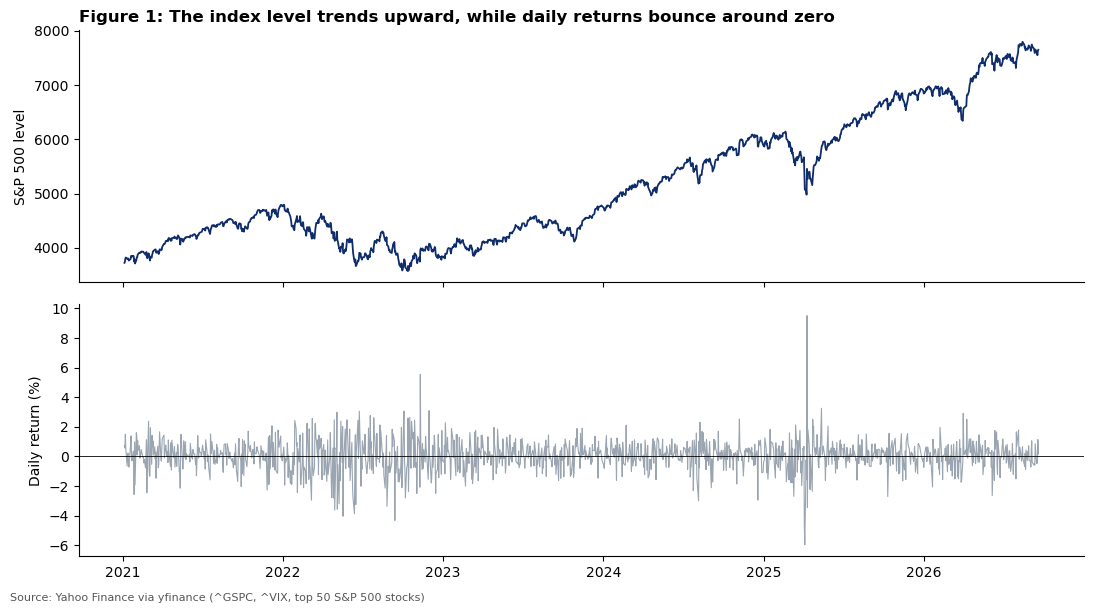

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(data.index, data["SP500"], color=NAVY, lw=1.3)
axes[0].set_ylabel("S&P 500 level")
title(
    axes[0],
    "Figure 1: The index level trends upward, while daily returns bounce around zero",
)
axes[1].plot(data.index, ret * 100, color=GREY, lw=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("Daily return (%)")
for ax in axes:
    style(ax)
fig.text(0.01, -0.01, SOURCE_NOTE, fontsize=8, color="#555")
fig.tight_layout()
fig.savefig(f"{OUT}/fig1_price_and_return.png", dpi=200, bbox_inches="tight")
plt.show()

**Supporting test (ADF):** price should be non-stationary (p > 0.05), returns stationary (p < 0.05).


In [ ]:
adf = pd.DataFrame(
    [
        {
            "Series": "S&P 500 level",
            "ADF stat": adfuller(data["SP500"])[0],
            "p-value": adfuller(data["SP500"])[1],
        },
        {
            "Series": "Daily return",
            "ADF stat": adfuller(ret)[0],
            "p-value": adfuller(ret)[1],
        },
    ]
).round(4)
adf["Stationary?"] = np.where(adf["p-value"] < 0.05, "Yes", "No")
adf

,Series,ADF stat,p-value,Stationary?
0,S&P 500 level,0.0925,0.9655,No
1,Daily return,-23.5326,0.0000,Yes


| Expected finding                         | So what                                      | Action                             | Leads to          |
| ---------------------------------------- | -------------------------------------------- | ---------------------------------- | ----------------- |
| Price trends up; returns bounce around 0 | Predicting price looks accurate but misleads | Predict next-day return, not price | Problem statement |

**Confirmed from the chart:** _[edit after running: what the chart actually shows]_


## 10. Figure 2: Correlation of the top 50 stocks with the index


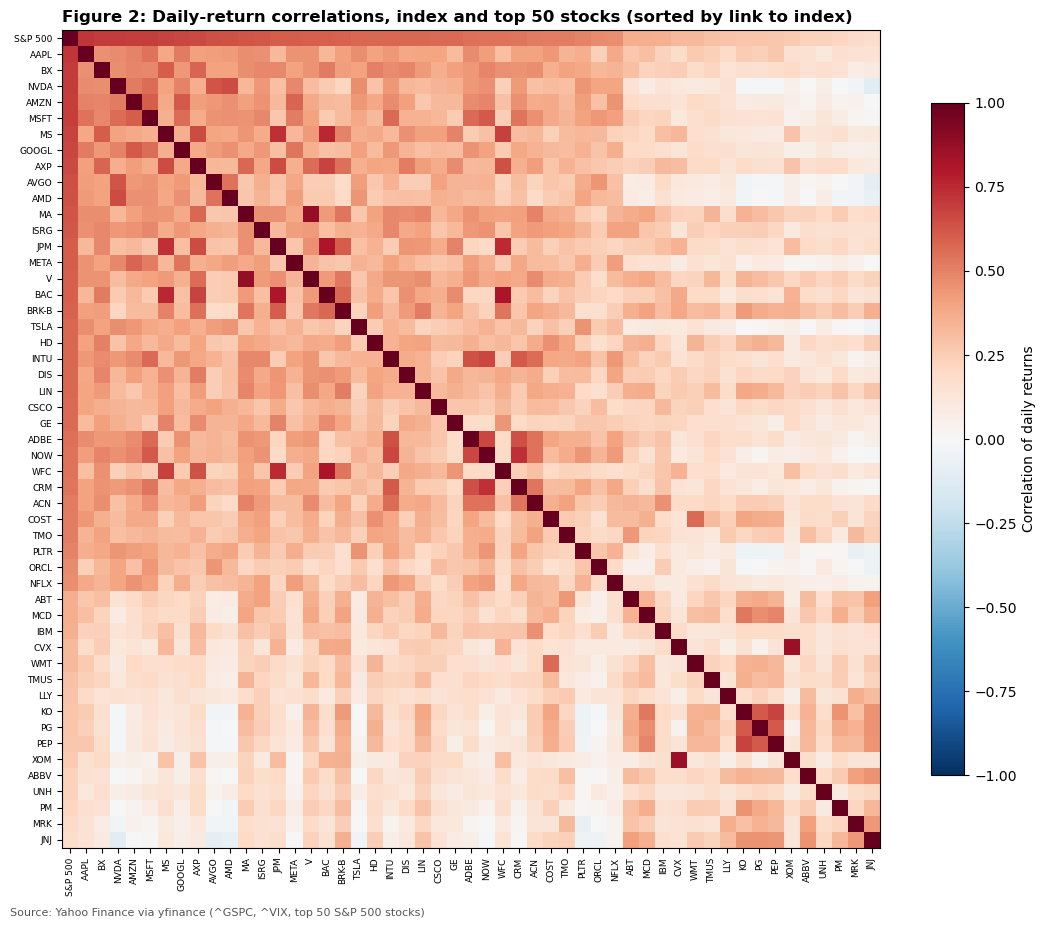

In [ ]:
corr_df = pd.concat([ret.rename("S&P 500"), stock_rets], axis=1)
corr_with_index = stock_rets.corrwith(ret).sort_values(ascending=False)
order = ["S&P 500"] + corr_with_index.index.tolist()
cm = corr_df[order].corr()

fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(cm.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(order)), order, fontsize=6.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label("Correlation of daily returns")
title(
    ax,
    "Figure 2: Daily-return correlations, index and top 50 stocks (sorted by link to index)",
)
fig.text(0.01, 0.01, SOURCE_NOTE, fontsize=8, color="#555")
fig.tight_layout()
fig.savefig(f"{OUT}/fig2_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

**Figure 2b (slide-friendly version):** each stock's correlation with the index, one bar per stock.


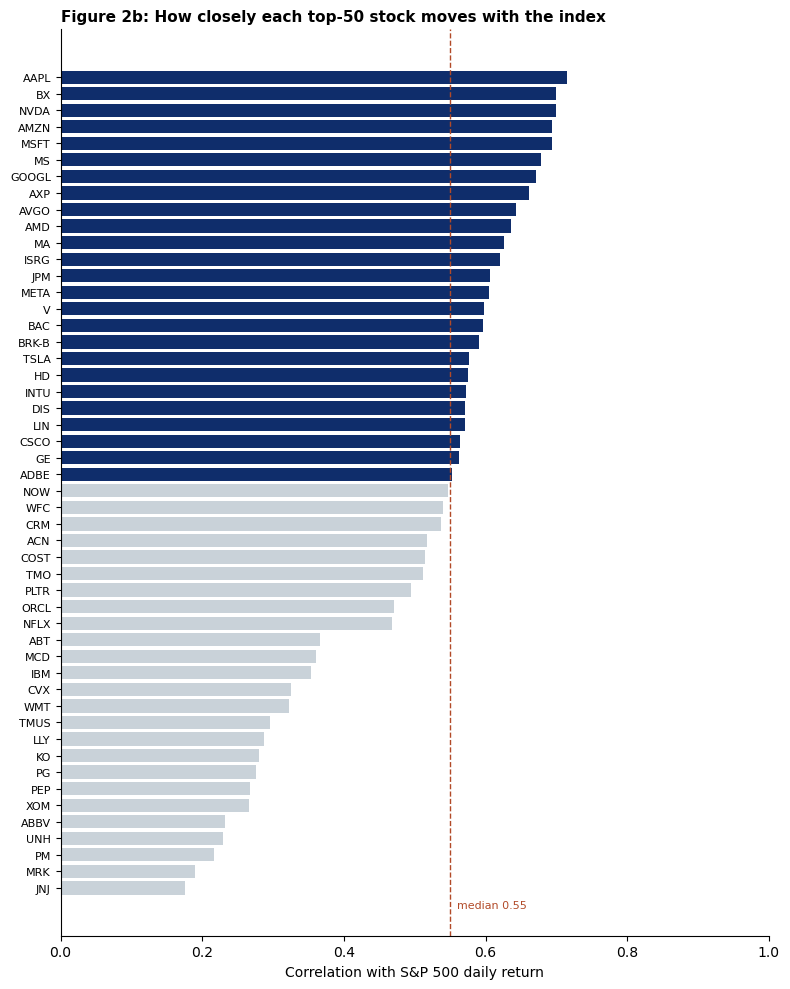

Correlation with index: median 0.55, range 0.18 (JNJ) to 0.71 (AAPL)
Average correlation between pairs of stocks: 0.27


In [ ]:
c = corr_with_index.sort_values()
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(c.index, c.values, color=[NAVY if v >= c.median() else LIGHT for v in c.values])
ax.axvline(c.median(), color=ACCENT, ls="--", lw=1)
ax.text(c.median() + 0.01, -1.2, f"median {c.median():.2f}", color=ACCENT, fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Correlation with S&P 500 daily return")
ax.set_xlim(0, 1)
title(ax, "Figure 2b: How closely each top-50 stock moves with the index", 11)
style(ax)
fig.tight_layout()
fig.savefig(f"{OUT}/fig2b_corr_with_index.png", dpi=200, bbox_inches="tight")
plt.show()

print(
    f"Correlation with index: median {c.median():.2f}, range {c.min():.2f} ({c.idxmin()}) "
    f"to {c.max():.2f} ({c.idxmax()})"
)
print(
    f"Average correlation between pairs of stocks: "
    f"{cm.iloc[1:, 1:].values[np.triu_indices(len(top), 1)].mean():.2f}"
)

| Expected finding                           | So what                                      | Action                                                          | Leads to             |
| ------------------------------------------ | -------------------------------------------- | --------------------------------------------------------------- | -------------------- |
| Largest stocks move closely with the index | The top 50 carry information about the index | Use them as inputs; DA-RNN attention picks the ones that matter | Future work (DA-RNN) |

**Confirmed from the chart:** _[edit after running: what the chart actually shows]_


## 11. Figure 3: VIX vs index returns


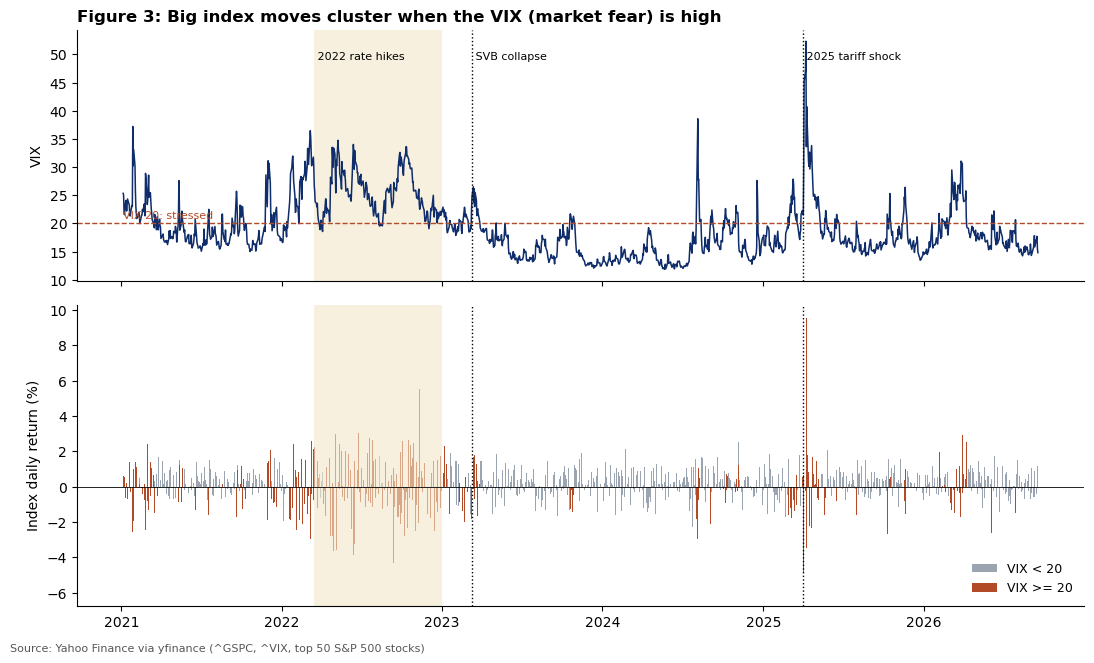

In [ ]:
EVENTS = [  # (label, start, end); end=None draws a single line
    ("2022 rate hikes", "2022-03-16", "2022-12-31"),
    ("SVB collapse", "2023-03-10", None),
    ("2025 tariff shock", "2025-04-02", None),
]
lo, hi = data.index.min(), data.index.max()

fig, axes = plt.subplots(
    2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]}
)
axes[0].plot(data.index, data["VIX"], color=NAVY, lw=1.1)
axes[0].axhline(VIX_STRESS, color=ACCENT, ls="--", lw=1)
axes[0].text(
    lo, VIX_STRESS + 0.8, f"VIX {VIX_STRESS}: stressed", color=ACCENT, fontsize=8
)
axes[0].set_ylabel("VIX")
title(axes[0], "Figure 3: Big index moves cluster when the VIX (market fear) is high")

stressed = data["VIX"] >= VIX_STRESS
axes[1].bar(
    data.index[~stressed],
    ret[~stressed] * 100,
    width=1.5,
    color=GREY,
    label=f"VIX < {VIX_STRESS}",
)
axes[1].bar(
    data.index[stressed],
    ret[stressed] * 100,
    width=1.5,
    color=ACCENT,
    label=f"VIX >= {VIX_STRESS}",
)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("Index daily return (%)")
axes[1].legend(frameon=False, loc="lower right", fontsize=9)

for label, a, b in EVENTS:
    a = pd.Timestamp(a)
    if not (lo <= a <= hi):
        continue
    for ax in axes:
        if b:
            ax.axvspan(a, min(pd.Timestamp(b), hi), color="#f2e6c9", alpha=0.6, lw=0)
        else:
            ax.axvline(a, color="black", ls=":", lw=1)
    axes[0].text(a, axes[0].get_ylim()[1] * 0.93, " " + label, fontsize=8, va="top")

for ax in axes:
    style(ax)
fig.text(0.01, -0.01, SOURCE_NOTE, fontsize=8, color="#555")
fig.tight_layout()
fig.savefig(f"{OUT}/fig3_vix_vs_returns.png", dpi=200, bbox_inches="tight")
plt.show()

**Figure 3b and calm vs stressed table:** does a higher VIX go with bigger moves?


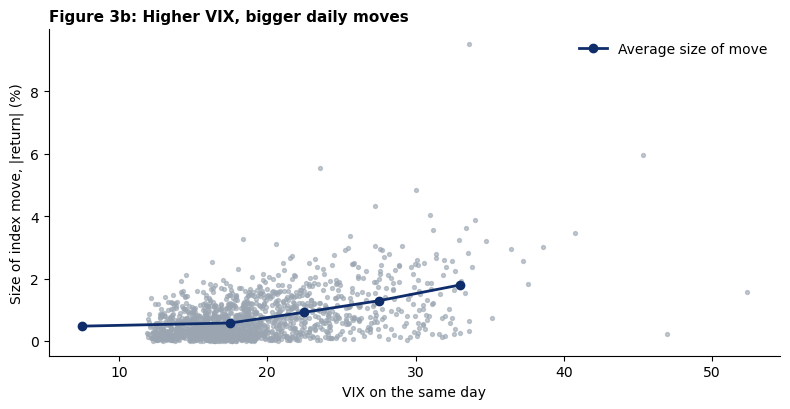

,Days,Std of daily return (%),Days with |move| > 2%
Calm (VIX < 20),946,0.687,6
Stressed (VIX >= 20),487,1.483,73


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(data["VIX"], ret.abs() * 100, s=8, color=GREY, alpha=0.6)
bins = pd.cut(data["VIX"], bins=[0, 15, 20, 25, 30, 100])
binned = (ret.abs() * 100).groupby(bins, observed=True).mean()
mids = [iv.mid if iv.right < 100 else iv.left + 3 for iv in binned.index]
ax.plot(mids, binned.values, "o-", color=NAVY, lw=2, label="Average size of move")
ax.set_xlabel("VIX on the same day")
ax.set_ylabel("Size of index move, |return| (%)")
title(ax, "Figure 3b: Higher VIX, bigger daily moves", 11)
ax.legend(frameon=False)
style(ax)
fig.tight_layout()
fig.savefig(f"{OUT}/fig3b_vix_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

regimes = pd.DataFrame(
    {
        "Days": [(~stressed).sum(), stressed.sum()],
        "Std of daily return (%)": [
            ret[~stressed].std() * 100,
            ret[stressed].std() * 100,
        ],
        "Days with |move| > 2%": [
            (ret[~stressed].abs() > 0.02).sum(),
            (ret[stressed].abs() > 0.02).sum(),
        ],
    },
    index=[f"Calm (VIX < {VIX_STRESS})", f"Stressed (VIX >= {VIX_STRESS})"],
).round(3)
regimes.to_csv(f"{OUT}/calm_vs_stressed.csv")
regimes

| Expected finding                                                     | So what                                | Action                                                 | Leads to                  |
| -------------------------------------------------------------------- | -------------------------------------- | ------------------------------------------------------ | ------------------------- |
| Big moves cluster when VIX is high (2022 rate hikes, March 2023 SVB) | Price history alone misses market fear | Add VIX and indicators; report calm vs stressed errors | Future work; crisis check |

**Confirmed from the chart:** _[edit after running: what the chart actually shows]_


## 12. Figure 4: Does yesterday's return predict today's? + spread of daily returns


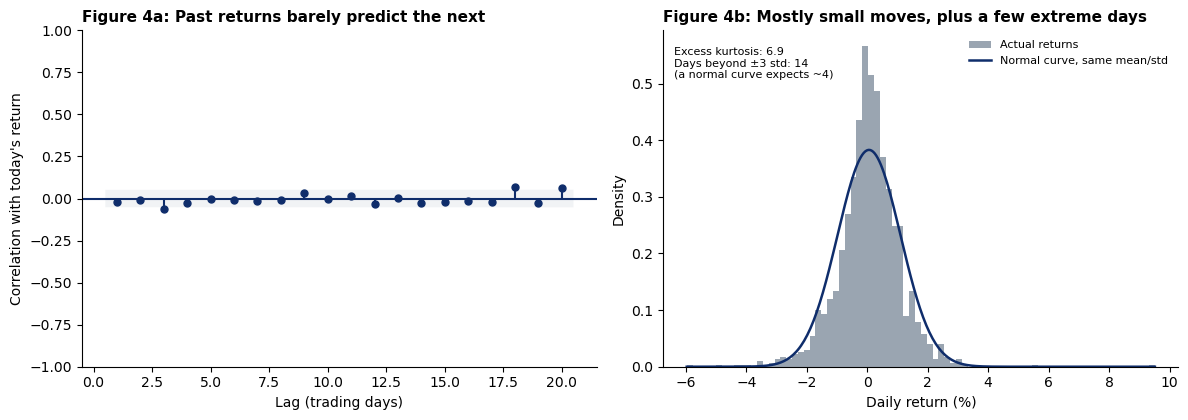

Ljung-Box test (p < 0.05 = some predictable pattern in past returns):


,lb_stat,lb_pvalue
lag,,
1,0.7661,0.3814
5,7.2698,0.2013
10,9.5473,0.4811


Most extreme days:


,return (%)
Date,
2025-04-04,-5.97
2025-04-03,-4.84
2022-09-13,-4.32
2022-05-18,-4.04
2022-06-13,-3.88
2022-04-29,-3.63
2022-05-05,-3.56
2025-04-10,-3.46
2022-08-26,-3.37


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

plot_acf(
    ret,
    lags=20,
    zero=False,
    ax=axes[0],
    color=NAVY,
    vlines_kwargs={"colors": NAVY},
    title=None,
)
for coll in axes[0].collections:
    if isinstance(coll, plt.matplotlib.collections.PolyCollection):
        coll.set_facecolor(LIGHT)
axes[0].set_xlabel("Lag (trading days)")
axes[0].set_ylabel("Correlation with today's return")
title(axes[0], "Figure 4a: Past returns barely predict the next", 11)

mu, sd = ret.mean() * 100, ret.std() * 100
axes[1].hist(ret * 100, bins=80, color=GREY, density=True, label="Actual returns")
x = np.linspace(ret.min() * 100, ret.max() * 100, 300)
axes[1].plot(
    x,
    stats.norm.pdf(x, mu, sd),
    color=NAVY,
    lw=1.8,
    label="Normal curve, same mean/std",
)
extreme = ret.abs() * 100 > 3 * sd
axes[1].set_xlabel("Daily return (%)")
axes[1].set_ylabel("Density")
title(axes[1], "Figure 4b: Mostly small moves, plus a few extreme days", 11)
axes[1].legend(frameon=False, fontsize=8)
axes[1].text(
    0.02,
    0.95,
    f"Excess kurtosis: {stats.kurtosis(ret):.1f}\n"
    f"Days beyond ±3 std: {extreme.sum()}\n(a normal curve expects ~{0.0027 * len(ret):.0f})",
    transform=axes[1].transAxes,
    fontsize=8,
    va="top",
)

for ax in axes:
    style(ax)
fig.tight_layout()
fig.savefig(f"{OUT}/fig4_autocorr_and_histogram.png", dpi=200, bbox_inches="tight")
plt.show()

lb = acorr_ljungbox(ret, lags=[1, 5, 10], return_df=True).round(4)
lb.index.name = "lag"
print("Ljung-Box test (p < 0.05 = some predictable pattern in past returns):")
display(lb)
print("Most extreme days:")
display((ret[extreme] * 100).round(2).sort_values().rename("return (%)").to_frame())

| Expected finding                                         | So what                                                           | Action                                                                     | Leads to            |
| -------------------------------------------------------- | ----------------------------------------------------------------- | -------------------------------------------------------------------------- | ------------------- |
| Past returns barely predict the next; a few extreme days | ARIMA will likely score close to naive; RMSE is hit by crash days | Report MAE too; move to models that learn complex patterns (XGBoost, LSTM) | Preliminary results |

**Confirmed from the chart:** _[edit after running: what the chart actually shows]_


## 13. EDA takeaway

Returns look random (Table 3, Figures 1 and 4) → so beating naive is the real test → but big stocks and market fear carry signal (Figures 2 and 3) → so later models add those inputs.

_[Edit after running: note anything the charts did not confirm.]_


In [22]:
sorted(os.listdir(OUT))

['calm_vs_stressed.csv',
 'fig1_price_and_return.png',
 'fig2_correlation_heatmap.png',
 'fig2b_corr_with_index.png',
 'fig3_vix_vs_returns.png',
 'fig3b_vix_scatter.png',
 'fig4_autocorr_and_histogram.png',
 'fig_top50_sectors.png',
 'fincare_model_data.csv',
 'table3_summary_stats.csv',
 'top50_tickers.csv']